# Post-Award Anomaly Detection

This notebook turns the cleaned procurement dataset into an offline, explainable post-award anomaly detection pipeline.
It uses a time-based split to reduce leakage risk, trains an `IsolationForest`, creates global feature importance through a surrogate regressor,
and exports human-readable top-3 drivers for each prediction.


In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def print_section(title):
    print("=" * 50)
    print(title)
    print("=" * 50)


def format_number(value):
    if pd.isna(value):
        return "missing"
    if isinstance(value, (int, np.integer)):
        return f"{int(value):,}"
    if isinstance(value, (float, np.floating)):
        return f"{value:,.4f}".rstrip("0").rstrip(".")
    return str(value)


def assign_severity(scores, medium_cutoff, anomaly_threshold):
    return np.select(
        [
            scores >= anomaly_threshold,
            scores >= medium_cutoff,
        ],
        ["high", "medium"],
        default="low",
    )


def to_builtin(value):
    if isinstance(value, dict):
        return {str(k): to_builtin(v) for k, v in value.items()}
    if isinstance(value, list):
        return [to_builtin(v) for v in value]
    if isinstance(value, tuple):
        return [to_builtin(v) for v in value]
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        return float(value)
    if isinstance(value, np.bool_):
        return bool(value)
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    return value


In [2]:
data = pd.read_csv("JakartaOCDSFinalData.csv", parse_dates=["date", "award_date"])
data = data.sort_values("award_date").reset_index(drop=True)

data["award_month"] = data["award_date"].dt.month
data["award_quarter"] = data["award_date"].dt.quarter
data["award_weekday"] = data["award_date"].dt.weekday
data["log_tender_minvalue"] = np.log1p(data["tender_minvalue"])
data["log_award_value"] = np.log1p(data["award_value"])
data["value_gap"] = data["award_value"] - data["tender_minvalue"]
data["title_word_count"] = data["tender_title"].fillna("").str.split().str.len()
data["award_title_word_count"] = data["award_title"].fillna("").str.split().str.len()
data["supplier_count"] = data["award_supplier"].fillna("").astype(str).str.split(",").str.len()
data["award_value_per_day"] = data["award_value"] / data["days_to_award"].replace(0, 1)
data["same_day_award_flag"] = (data["days_to_award"] == 0).astype(int)

model_numeric_features = [
    "tender_minvalue",
    "award_value",
    "days_to_award",
    "budget_utilization_ratio",
    "value_gap",
    "log_tender_minvalue",
    "log_award_value",
    "title_word_count",
    "award_title_word_count",
    "supplier_count",
    "award_value_per_day",
    "same_day_award_flag",
    "award_month",
    "award_quarter",
    "award_weekday",
]

excluded_from_model = {
    "buyer_name": "Excluded from the model because buyer identity is heavily imbalanced and would add weak signal.",
    "tender_status": "Excluded from the model because it is effectively constant in the cleaned dataset.",
}

model_categorical_features = [
    "mainprocurementcategory",
]

explanation_numeric_features = [
    "tender_minvalue",
    "award_value",
    "days_to_award",
    "budget_utilization_ratio",
    "value_gap",
    "supplier_count",
    "title_word_count",
    "award_value_per_day",
]

print_section("POST-AWARD DATASET")
print(f"Rows            : {len(data)}")
print(f"Columns         : {len(data.columns)}")
print(f"Award date span : {data['award_date'].min().date()} -> {data['award_date'].max().date()}")
print(f"Suppliers       : {data['award_supplier'].nunique()}")
print(f"Categories      : {data['mainprocurementcategory'].nunique()}")
print("\nSelected model features:")
print(model_numeric_features + model_categorical_features)
print("\nExcluded fields:")
for field, note in excluded_from_model.items():
    print(f"- {field}: {note}")
print("\nSample rows:")
display(data[["award_date", "buyer_name", "mainprocurementcategory", "tender_minvalue", "award_value", "days_to_award", "budget_utilization_ratio"]].head(5))


POST-AWARD DATASET
Rows            : 8678
Columns         : 23
Award date span : 2014-12-24 -> 2023-10-18
Suppliers       : 2710
Categories      : 3

Selected model features:
['tender_minvalue', 'award_value', 'days_to_award', 'budget_utilization_ratio', 'value_gap', 'log_tender_minvalue', 'log_award_value', 'title_word_count', 'award_title_word_count', 'supplier_count', 'award_value_per_day', 'same_day_award_flag', 'award_month', 'award_quarter', 'award_weekday', 'mainprocurementcategory']

Excluded fields:
- buyer_name: Excluded from the model because buyer identity is heavily imbalanced and would add weak signal.
- tender_status: Excluded from the model because it is effectively constant in the cleaned dataset.

Sample rows:


,award_date,buyer_name,mainprocurementcategory,tender_minvalue,award_value,days_to_award,budget_utilization_ratio
0,2014-12-24,Pemerintah Daerah Provinsi Dki Jakarta,Goods,1.499502e+09,1.157888e+09,16,0.772182
1,2015-04-15,Pemerintah Daerah Provinsi Dki Jakarta,Services,1.988607e+10,1.934999e+10,15,0.973043
2,2015-04-17,Pemerintah Daerah Provinsi Dki Jakarta,Services,1.612680e+09,1.263166e+09,15,0.783271
3,2015-04-23,Pemerintah Daerah Provinsi Dki Jakarta,Goods,6.271924e+09,6.196783e+09,113,0.988019
4,2015-04-24,Pemerintah Daerah Provinsi Dki Jakarta,Goods,9.039069e+09,6.867945e+09,115,0.759807


In [3]:
artifact_dir = Path("artifacts/post_award_anomaly")
artifact_dir.mkdir(parents=True, exist_ok=True)

split_index = int(len(data) * 0.85)
train_data = data.iloc[:split_index].copy()
test_data = data.iloc[split_index:].copy()

train_max_date = train_data["award_date"].max()
test_min_date = test_data["award_date"].min()

print_section("TIME-BASED SPLIT")
print(f"Train rows      : {len(train_data)}")
print(f"Test rows       : {len(test_data)}")
print(f"Train max date  : {train_max_date.date()}")
print(f"Test min date   : {test_min_date.date()}")
print(f"Leakage check   : {train_max_date <= test_min_date}")

assert train_max_date <= test_min_date, "Temporal leakage detected: training overlaps with test period."

train_export_path = artifact_dir / "train_post_award_split.csv"
test_export_path = artifact_dir / "test_post_award_split.csv"
train_data.to_csv(train_export_path, index=False)
test_data.to_csv(test_export_path, index=False)

print(f"Saved train split: {train_export_path.resolve()}")
print(f"Saved test split : {test_export_path.resolve()}")


TIME-BASED SPLIT
Train rows      : 7376
Test rows       : 1302
Train max date  : 2022-03-23
Test min date   : 2022-03-24
Leakage check   : True
Saved train split: C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly\train_post_award_split.csv
Saved test split : C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly\test_post_award_split.csv


In [4]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            model_numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", encoder),
                ]
            ),
            model_categorical_features,
        ),
    ]
)

X_train = preprocessor.fit_transform(train_data[model_numeric_features + model_categorical_features])
X_test = preprocessor.transform(test_data[model_numeric_features + model_categorical_features])

contamination = 0.03
model = IsolationForest(
    n_estimators=300,
    contamination=contamination,
    random_state=42,
)
model.fit(X_train)

train_scores = -model.score_samples(X_train)
test_scores = -model.score_samples(X_test)
medium_cutoff = float(np.quantile(train_scores, 0.70))
threshold = float(np.quantile(train_scores, 1 - contamination))

train_data["anomaly_score"] = train_scores
test_data["anomaly_score"] = test_scores
train_data["prediction_label"] = np.where(train_scores >= threshold, "anomaly", "normal")
test_data["prediction_label"] = np.where(test_scores >= threshold, "anomaly", "normal")
train_data["anomaly_flag"] = (train_data["prediction_label"] == "anomaly").astype(int)
test_data["anomaly_flag"] = (test_data["prediction_label"] == "anomaly").astype(int)
train_data["severity_band"] = assign_severity(train_scores, medium_cutoff, threshold)
test_data["severity_band"] = assign_severity(test_scores, medium_cutoff, threshold)

config = {
    "pipeline_type": "post_award_anomaly_detection",
    "split_strategy": "time_based_85_15",
    "contamination": contamination,
    "medium_cutoff": medium_cutoff,
    "anomaly_threshold": threshold,
    "numeric_features": model_numeric_features,
    "categorical_features": model_categorical_features,
    "explanation_numeric_features": explanation_numeric_features,
    "excluded_from_model": excluded_from_model,
}
joblib.dump(model, artifact_dir / "isolation_forest.joblib")
joblib.dump(preprocessor, artifact_dir / "preprocessor.joblib")
(artifact_dir / "model_config.json").write_text(json.dumps(to_builtin(config), indent=2), encoding="utf-8")

print_section("MODEL RESULTS")
print(f"Medium score cutoff     : {medium_cutoff:.6f}")
print(f"Train anomaly threshold : {threshold:.6f}")
print(f"Train anomalies         : {train_data['anomaly_flag'].sum()} / {len(train_data)} ({train_data['anomaly_flag'].mean():.2%})")
print(f"Test anomalies          : {test_data['anomaly_flag'].sum()} / {len(test_data)} ({test_data['anomaly_flag'].mean():.2%})")
print("\nTest severity bands:")
print(test_data['severity_band'].value_counts().to_string())
print("\nSaved model artifacts:")
print(f"- {(artifact_dir / 'isolation_forest.joblib').resolve()}")
print(f"- {(artifact_dir / 'preprocessor.joblib').resolve()}")
print(f"- {(artifact_dir / 'model_config.json').resolve()}")
print("\nHighest-scoring test records:")
display(
    test_data[
        [
            "award_date",
            "buyer_name",
            "mainprocurementcategory",
            "tender_minvalue",
            "award_value",
            "days_to_award",
            "budget_utilization_ratio",
            "anomaly_score",
            "severity_band",
            "prediction_label",
        ]
    ]
    .sort_values("anomaly_score", ascending=False)
    .head(10)
)


MODEL RESULTS
Medium score cutoff     : 0.459542
Train anomaly threshold : 0.588172
Train anomalies         : 222 / 7376 (3.01%)
Test anomalies          : 36 / 1302 (2.76%)

Test severity bands:
severity_band
low       951
medium    315
high       36

Saved model artifacts:
- C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly\isolation_forest.joblib
- C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly\preprocessor.joblib
- C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly\model_config.json

Highest-scoring test records:


,award_date,buyer_name,mainprocurementcategory,tender_minvalue,award_value,days_to_award,budget_utilization_ratio,anomaly_score,severity_band,prediction_label
8129,2023-01-16,Pemerintah Daerah Provinsi Dki Jakarta,Works,9.078990e+11,7.871680e+11,200,0.867022,0.767747,high,anomaly
8130,2023-01-16,Pemerintah Daerah Provinsi Dki Jakarta,Works,6.608655e+11,6.207725e+11,200,0.939333,0.764292,high,anomaly
8676,2023-10-17,Pemerintah Daerah Provinsi Dki Jakarta,Works,4.777265e+11,3.821812e+11,112,0.800000,0.754344,high,anomaly
7560,2022-05-23,Pemerintah Daerah Provinsi Dki Jakarta,Works,2.734985e+11,2.520251e+11,82,0.921486,0.727271,high,anomaly
8581,2023-08-11,Pemerintah Daerah Provinsi Dki Jakarta,Services,2.270403e+11,2.085774e+11,91,0.918680,0.714290,high,anomaly
8609,2023-08-30,Pemerintah Daerah Provinsi Dki Jakarta,Works,2.011225e+11,1.911450e+11,75,0.950391,0.706328,high,anomaly
7539,2022-05-19,Pemerintah Daerah Provinsi Dki Jakarta,Works,1.971044e+11,1.950938e+11,37,0.989799,0.702171,high,anomaly
8582,2023-08-11,Pemerintah Daerah Provinsi Dki Jakarta,Services,2.037597e+11,1.975000e+11,91,0.969279,0.700402,high,anomaly
8494,2023-07-11,Pemerintah Daerah Provinsi Dki Jakarta,Works,1.302273e+11,1.186307e+11,99,0.910951,0.674580,high,anomaly
7636,2022-06-08,Pemerintah Daerah Provinsi Dki Jakarta,Works,9.050766e+10,7.240385e+10,99,0.799975,0.667150,high,anomaly


GLOBAL EXPLAINABILITY
Global importance is computed with permutation importance on a surrogate regressor trained to approximate anomaly scores.
            raw_feature  importance_mean  importance_std
    award_value_per_day         0.253833        0.008600
    log_tender_minvalue         0.124078        0.002116
mainprocurementcategory         0.120760        0.006793
        tender_minvalue         0.117353        0.002115
            award_month         0.053152        0.002764
       title_word_count         0.043003        0.000634
 award_title_word_count         0.040646        0.000725
          award_quarter         0.026368        0.001445
          days_to_award         0.017911        0.001229
              value_gap         0.017310        0.001148


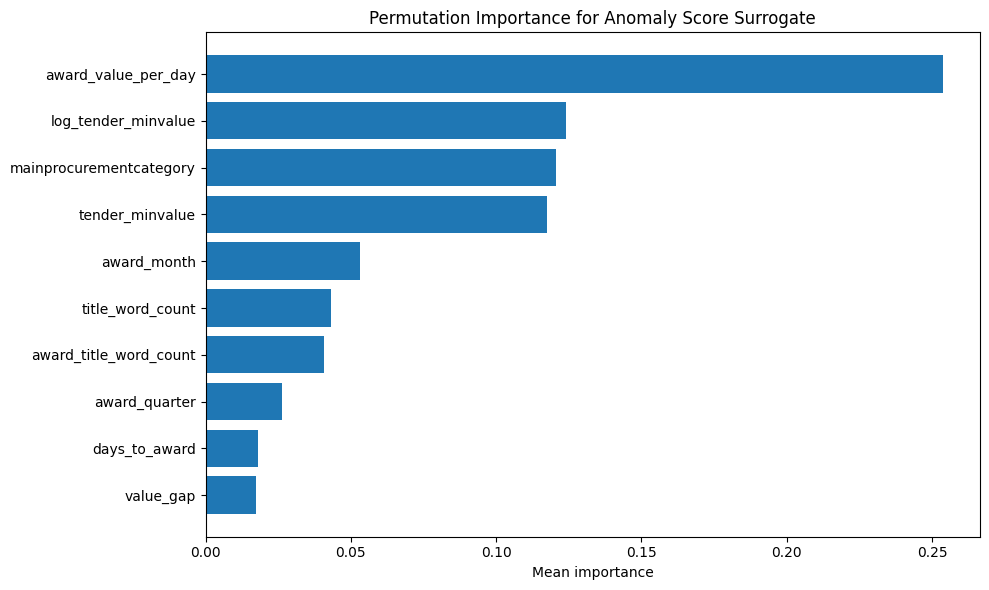

In [5]:
feature_names = preprocessor.get_feature_names_out()

surrogate = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1,
)
surrogate.fit(X_train, train_scores)

perm = permutation_importance(
    surrogate,
    X_test,
    test_scores,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

global_importance = pd.DataFrame(
    {
        "feature": feature_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
)

def map_raw_feature(feature_name):
    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "")
    if feature_name.startswith("cat__mainprocurementcategory_"):
        return "mainprocurementcategory"
    return feature_name


global_importance["raw_feature"] = global_importance["feature"].apply(map_raw_feature)
global_importance = (
    global_importance.groupby("raw_feature", as_index=False)[["importance_mean", "importance_std"]]
    .sum()
    .sort_values("importance_mean", ascending=False)
)
global_importance.to_csv(artifact_dir / "global_feature_importance.csv", index=False)

print_section("GLOBAL EXPLAINABILITY")
print("Global importance is computed with permutation importance on a surrogate regressor trained to approximate anomaly scores.")
print(global_importance.head(10).to_string(index=False))

top_global = global_importance.head(10).sort_values("importance_mean")
plt.figure(figsize=(10, 6))
plt.barh(top_global["raw_feature"], top_global["importance_mean"])
plt.title("Permutation Importance for Anomaly Score Surrogate")
plt.xlabel("Mean importance")
plt.tight_layout()
plt.show()


In [6]:
normal_reference = train_data.loc[train_data["prediction_label"] == "normal"].copy()

numeric_reference = {}
for col in explanation_numeric_features:
    series = normal_reference[col].dropna()
    median = float(series.median())
    q1 = float(series.quantile(0.25))
    q3 = float(series.quantile(0.75))
    spread = float(q3 - q1)
    if spread <= 0:
        spread = float(series.std(ddof=0))
    if spread <= 0:
        spread = 1.0
    numeric_reference[col] = {"median": median, "spread": spread}

categorical_reference = {}
for col in model_categorical_features:
    categorical_reference[col] = {str(k): float(v) for k, v in normal_reference[col].value_counts(normalize=True).to_dict().items()}

explanation_baselines = {
    "numeric_reference": numeric_reference,
    "categorical_reference": categorical_reference,
    "explanation_numeric_features": explanation_numeric_features,
    "categorical_features": model_categorical_features,
    "local_explanation_method": "Deviation from normal-baseline medians for numeric features and rarity against normal-baseline frequencies for categorical features.",
}
(artifact_dir / "explanation_baselines.json").write_text(json.dumps(to_builtin(explanation_baselines), indent=2), encoding="utf-8")


def explain_prediction(row):
    is_anomaly = row["prediction_label"] == "anomaly"
    contributions = []

    for col in explanation_numeric_features:
        baseline = numeric_reference[col]["median"]
        spread = numeric_reference[col]["spread"]
        value = row[col]
        deviation = abs(float(value) - baseline) / spread

        if is_anomaly:
            impact = "positive"
            if float(value) >= baseline:
                reason = f"{col} is higher than the normal baseline ({format_number(value)} vs {format_number(baseline)})."
            else:
                reason = f"{col} is lower than the normal baseline ({format_number(value)} vs {format_number(baseline)})."
            score = deviation
        else:
            impact = "negative"
            reason = f"{col} stays close to the normal baseline ({format_number(value)} vs {format_number(baseline)})."
            score = 1 / (1 + deviation)

        contributions.append(
            {
                "feature": col,
                "score": float(score),
                "impact": impact,
                "reason": reason,
            }
        )

    for col in model_categorical_features:
        value = str(row[col])
        frequency = float(categorical_reference[col].get(value, 0.0))

        if is_anomaly:
            impact = "positive"
            score = 1.0 - frequency
            if frequency == 0:
                reason = f"{col}='{value}' was not seen in the normal training baseline."
            else:
                reason = f"{col}='{value}' is rare in the normal training baseline ({frequency:.2%})."
        else:
            impact = "negative"
            score = frequency
            reason = f"{col}='{value}' is common in the normal training baseline ({frequency:.2%})."

        contributions.append(
            {
                "feature": col,
                "score": float(score),
                "impact": impact,
                "reason": reason,
            }
        )

    top_contributions = sorted(contributions, key=lambda item: item["score"], reverse=True)[:3]

    result = {}
    summary_lines = []
    for idx, item in enumerate(top_contributions, start=1):
        result[f"top_{idx}_feature"] = item["feature"]
        result[f"top_{idx}_impact"] = item["impact"]
        result[f"top_{idx}_reason"] = item["reason"]
        summary_lines.append(f"{idx}. {item['feature']} ({item['impact']}): {item['reason']}")

    label_text = "Anomalous" if is_anomaly else "Normal"
    result["human_readable_explanation"] = f"{label_text} transaction. " + " ".join(summary_lines)
    return pd.Series(result)


train_explanations = train_data.apply(explain_prediction, axis=1)
test_explanations = test_data.apply(explain_prediction, axis=1)

train_output = pd.concat([train_data.reset_index(drop=True), train_explanations.reset_index(drop=True)], axis=1)
test_output = pd.concat([test_data.reset_index(drop=True), test_explanations.reset_index(drop=True)], axis=1)

train_output_path = artifact_dir / "train_predictions_with_explanations.csv"
test_output_path = artifact_dir / "test_predictions_with_explanations.csv"
anomaly_output_path = artifact_dir / "test_anomalies_only.csv"

train_output.to_csv(train_output_path, index=False)
test_output.to_csv(test_output_path, index=False)
test_output.loc[test_output["prediction_label"] == "anomaly"] \
    .sort_values("anomaly_score", ascending=False) \
    .to_csv(anomaly_output_path, index=False)

normal_demo = test_output.loc[test_output["prediction_label"] == "normal"].copy()
if normal_demo.empty:
    normal_demo = test_output.sort_values("anomaly_score", ascending=True).head(1).copy()
else:
    normal_demo["demo_distance"] = (normal_demo["anomaly_score"] - normal_demo["anomaly_score"].median()).abs()
    normal_demo = normal_demo.sort_values("demo_distance").head(1).drop(columns=["demo_distance"])

borderline_demo = test_output.loc[test_output["prediction_label"] == "normal"].copy()
if borderline_demo.empty:
    borderline_demo = test_output.sort_values("anomaly_score", ascending=False).head(1).copy()
else:
    borderline_demo["demo_distance"] = (borderline_demo["anomaly_score"] - threshold).abs()
    borderline_demo = borderline_demo.sort_values("demo_distance").head(1).drop(columns=["demo_distance"])

anomaly_demo = test_output.loc[test_output["prediction_label"] == "anomaly"].sort_values("anomaly_score", ascending=False).head(1).copy()
if anomaly_demo.empty:
    anomaly_demo = test_output.sort_values("anomaly_score", ascending=False).head(1).copy()

demo_cases = pd.concat([normal_demo, borderline_demo, anomaly_demo], ignore_index=True)
demo_cases["demo_case_label"] = ["normal_demo", "borderline_demo", "anomaly_demo"]
demo_input_columns = [
    "demo_case_label",
    "date",
    "buyer_name",
    "tender_title",
    "mainprocurementcategory",
    "tender_minvalue",
    "tender_status",
    "award_title",
    "award_date",
    "award_value",
    "award_supplier",
    "days_to_award",
    "budget_utilization_ratio",
]
demo_output_columns = demo_input_columns + ["anomaly_score", "severity_band", "prediction_label", "human_readable_explanation"]
demo_cases[demo_input_columns].to_csv(artifact_dir / "demo_input_cases.csv", index=False)
demo_cases[demo_output_columns].to_csv(artifact_dir / "demo_expected_outputs.csv", index=False)

print_section("LOCAL EXPLANATIONS")
print(f"Saved train predictions : {train_output_path.resolve()}")
print(f"Saved test predictions  : {test_output_path.resolve()}")
print(f"Saved anomaly-only file : {anomaly_output_path.resolve()}")
print(f"Saved baselines         : {(artifact_dir / 'explanation_baselines.json').resolve()}")
print(f"Saved demo inputs       : {(artifact_dir / 'demo_input_cases.csv').resolve()}")
print("\nHighest-scoring explained anomalies:")
display(
    test_output[
        [
            "award_date",
            "buyer_name",
            "mainprocurementcategory",
            "award_value",
            "days_to_award",
            "anomaly_score",
            "severity_band",
            "prediction_label",
            "top_1_feature",
            "top_1_impact",
            "top_1_reason",
            "human_readable_explanation",
        ]
    ]
    .sort_values("anomaly_score", ascending=False)
    .head(10)
)


LOCAL EXPLANATIONS
Saved train predictions : C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly\train_predictions_with_explanations.csv
Saved test predictions  : C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly\test_predictions_with_explanations.csv
Saved anomaly-only file : C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly\test_anomalies_only.csv
Saved baselines         : C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly\explanation_baselines.json
Saved demo inputs       : C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly\demo_input_cases.csv

Highest-scoring explained anomalies:


,award_date,buyer_name,mainprocurementcategory,award_value,days_to_award,anomaly_score,severity_band,prediction_label,top_1_feature,top_1_impact,top_1_reason,human_readable_explanation
753,2023-01-16,Pemerintah Daerah Provinsi Dki Jakarta,Works,7.871680e+11,200,0.767747,high,anomaly,value_gap,positive,value_gap is lower than the normal baseline (-...,Anomalous transaction. 1. value_gap (positive)...
754,2023-01-16,Pemerintah Daerah Provinsi Dki Jakarta,Works,6.207725e+11,200,0.764292,high,anomaly,award_value,positive,award_value is higher than the normal baseline...,Anomalous transaction. 1. award_value (positiv...
1300,2023-10-17,Pemerintah Daerah Provinsi Dki Jakarta,Works,3.821812e+11,112,0.754344,high,anomaly,value_gap,positive,value_gap is lower than the normal baseline (-...,Anomalous transaction. 1. value_gap (positive)...
184,2022-05-23,Pemerintah Daerah Provinsi Dki Jakarta,Works,2.520251e+11,82,0.727271,high,anomaly,award_value,positive,award_value is higher than the normal baseline...,Anomalous transaction. 1. award_value (positiv...
1205,2023-08-11,Pemerintah Daerah Provinsi Dki Jakarta,Services,2.085774e+11,91,0.714290,high,anomaly,award_value,positive,award_value is higher than the normal baseline...,Anomalous transaction. 1. award_value (positiv...
1233,2023-08-30,Pemerintah Daerah Provinsi Dki Jakarta,Works,1.911450e+11,75,0.706328,high,anomaly,award_value,positive,award_value is higher than the normal baseline...,Anomalous transaction. 1. award_value (positiv...
163,2022-05-19,Pemerintah Daerah Provinsi Dki Jakarta,Works,1.950938e+11,37,0.702171,high,anomaly,award_value,positive,award_value is higher than the normal baseline...,Anomalous transaction. 1. award_value (positiv...
1206,2023-08-11,Pemerintah Daerah Provinsi Dki Jakarta,Services,1.975000e+11,91,0.700402,high,anomaly,award_value,positive,award_value is higher than the normal baseline...,Anomalous transaction. 1. award_value (positiv...
1118,2023-07-11,Pemerintah Daerah Provinsi Dki Jakarta,Works,1.186307e+11,99,0.674580,high,anomaly,award_value,positive,award_value is higher than the normal baseline...,Anomalous transaction. 1. award_value (positiv...
260,2022-06-08,Pemerintah Daerah Provinsi Dki Jakarta,Works,7.240385e+10,99,0.667150,high,anomaly,value_gap,positive,value_gap is lower than the normal baseline (-...,Anomalous transaction. 1. value_gap (positive)...


In [7]:
category_reference = train_data.groupby("mainprocurementcategory").agg(
    award_value_p99=("award_value", lambda s: float(s.quantile(0.99))),
    days_to_award_p95=("days_to_award", lambda s: float(s.quantile(0.95))),
    budget_ratio_p05=("budget_utilization_ratio", lambda s: float(s.quantile(0.05))),
    budget_ratio_p95=("budget_utilization_ratio", lambda s: float(s.quantile(0.95))),
).reset_index()

global_reference = {
    "award_value_p99": float(train_data["award_value"].quantile(0.99)),
    "days_to_award_p95": float(train_data["days_to_award"].quantile(0.95)),
    "budget_ratio_p05": float(train_data["budget_utilization_ratio"].quantile(0.05)),
    "budget_ratio_p95": float(train_data["budget_utilization_ratio"].quantile(0.95)),
}

reference_thresholds = {
    "category_reference": category_reference.to_dict(orient="records"),
    "global_reference": global_reference,
    "proxy_rule_columns": [
        "rule_over_budget",
        "rule_same_day_award",
        "rule_extreme_award_value",
        "rule_long_award_duration",
        "rule_extreme_budget_ratio",
    ],
}
(artifact_dir / "reference_thresholds.json").write_text(json.dumps(to_builtin(reference_thresholds), indent=2), encoding="utf-8")

test_eval = test_output.merge(category_reference, on="mainprocurementcategory", how="left")
for col, fallback_value in global_reference.items():
    test_eval[col] = test_eval[col].fillna(fallback_value)

test_eval["rule_over_budget"] = test_eval["budget_utilization_ratio"] > 1.0
test_eval["rule_same_day_award"] = test_eval["days_to_award"] == 0
test_eval["rule_extreme_award_value"] = test_eval["award_value"] >= test_eval["award_value_p99"]
test_eval["rule_long_award_duration"] = test_eval["days_to_award"] >= test_eval["days_to_award_p95"]
test_eval["rule_extreme_budget_ratio"] = (
    (test_eval["budget_utilization_ratio"] <= test_eval["budget_ratio_p05"])
    | (test_eval["budget_utilization_ratio"] >= test_eval["budget_ratio_p95"])
)

proxy_rule_columns = reference_thresholds["proxy_rule_columns"]

test_eval["proxy_rule_count"] = test_eval[proxy_rule_columns].sum(axis=1)
test_eval["proxy_anomaly_flag"] = (
    (test_eval["proxy_rule_count"] >= 2)
    | test_eval["rule_over_budget"]
    | test_eval["rule_same_day_award"]
).astype(int)
test_eval["proxy_validation_tier"] = np.select(
    [
        test_eval["proxy_anomaly_flag"] == 1,
        test_eval["proxy_rule_count"] == 1,
    ],
    ["strong_proxy_anomaly", "watchlist_proxy_signal"],
    default="baseline_proxy_normal",
)


def build_proxy_reason(row):
    reasons = []
    if row["rule_over_budget"]:
        reasons.append("award value exceeds the tender minimum budget")
    if row["rule_same_day_award"]:
        reasons.append("award was completed on the same day")
    if row["rule_extreme_award_value"]:
        reasons.append("award value is in the historical top 1% for its category")
    if row["rule_long_award_duration"]:
        reasons.append("days to award is in the historical top 5% for its category")
    if row["rule_extreme_budget_ratio"]:
        reasons.append("budget utilization ratio is historically extreme for its category")
    return "; ".join(reasons) if reasons else "no proxy rule triggered"


test_eval["proxy_reason"] = test_eval.apply(build_proxy_reason, axis=1)

proxy_y_true = test_eval["proxy_anomaly_flag"].astype(int)
proxy_y_pred = test_eval["anomaly_flag"].astype(int)
proxy_precision = precision_score(proxy_y_true, proxy_y_pred, zero_division=0)
proxy_recall = recall_score(proxy_y_true, proxy_y_pred, zero_division=0)
proxy_f1 = f1_score(proxy_y_true, proxy_y_pred, zero_division=0)
proxy_confusion = confusion_matrix(proxy_y_true, proxy_y_pred, labels=[0, 1])

baseline_proxy_rate = float(proxy_y_true.mean())
model_alert_rate = float(proxy_y_pred.mean())
model_alert_proxy_hit_rate = float(test_eval.loc[test_eval["anomaly_flag"] == 1, "proxy_anomaly_flag"].mean()) if (test_eval["anomaly_flag"] == 1).any() else 0.0
top_n = max(1, int(round(len(test_eval) * contamination)))
top_score_slice = test_eval.sort_values("anomaly_score", ascending=False).head(top_n)
precision_at_top_n = float(top_score_slice["proxy_anomaly_flag"].mean())
proxy_capture_at_top_n = float(top_score_slice["proxy_anomaly_flag"].sum() / max(1, test_eval["proxy_anomaly_flag"].sum()))
score_rule_correlation = test_eval["anomaly_score"].corr(test_eval["proxy_rule_count"], method="spearman")
if pd.isna(score_rule_correlation):
    score_rule_correlation = 0.0

rule_breakdown = pd.DataFrame(
    {
        "rule": proxy_rule_columns,
        "count": [int(test_eval[col].sum()) for col in proxy_rule_columns],
    }
)
rule_breakdown["rate"] = rule_breakdown["count"] / len(test_eval)

evaluation_summary = {
    "proxy_positive_count": int(test_eval["proxy_anomaly_flag"].sum()),
    "proxy_positive_rate": baseline_proxy_rate,
    "model_alert_count": int(test_eval["anomaly_flag"].sum()),
    "model_alert_rate": model_alert_rate,
    "proxy_precision": float(proxy_precision),
    "proxy_recall": float(proxy_recall),
    "proxy_f1": float(proxy_f1),
    "model_alert_proxy_hit_rate": model_alert_proxy_hit_rate,
    "precision_at_top_n": precision_at_top_n,
    "proxy_capture_at_top_n": proxy_capture_at_top_n,
    "spearman_score_vs_rule_count": float(score_rule_correlation),
    "confusion_matrix": {
        "tn": int(proxy_confusion[0, 0]),
        "fp": int(proxy_confusion[0, 1]),
        "fn": int(proxy_confusion[1, 0]),
        "tp": int(proxy_confusion[1, 1]),
    },
}

evaluation_summary_path = artifact_dir / "evaluation_summary.json"
rule_breakdown_path = artifact_dir / "proxy_rule_breakdown.csv"
test_eval_output_path = artifact_dir / "test_predictions_with_proxy_evaluation.csv"

evaluation_summary_path.write_text(json.dumps(evaluation_summary, indent=2), encoding="utf-8")
rule_breakdown.to_csv(rule_breakdown_path, index=False)
test_eval.to_csv(test_eval_output_path, index=False)

print_section("RETROSPECTIVE EVALUATION")
print("Proxy labels are rule-based retrospective indicators, not confirmed fraud labels.")
print(f"Proxy positive rate         : {baseline_proxy_rate:.2%}")
print(f"Model alert rate            : {model_alert_rate:.2%}")
print(f"Proxy precision             : {proxy_precision:.2%}")
print(f"Proxy recall                : {proxy_recall:.2%}")
print(f"Proxy F1                    : {proxy_f1:.2%}")
print(f"Alert hit rate              : {model_alert_proxy_hit_rate:.2%}")
print(f"Precision@Top{top_n}          : {precision_at_top_n:.2%}")
print(f"Proxy capture@Top{top_n}      : {proxy_capture_at_top_n:.2%}")
print(f"Score vs rule-count rho     : {score_rule_correlation:.3f}")
print("\nProxy rule breakdown:")
print(rule_breakdown.to_string(index=False))
print("\nSaved evaluation files:")
print(f"- {evaluation_summary_path.resolve()}")
print(f"- {rule_breakdown_path.resolve()}")
print(f"- {test_eval_output_path.resolve()}")
print("\nTop evaluated anomalies:")
display(
    test_eval[
        [
            "award_date",
            "buyer_name",
            "mainprocurementcategory",
            "award_value",
            "days_to_award",
            "budget_utilization_ratio",
            "anomaly_score",
            "prediction_label",
            "proxy_anomaly_flag",
            "proxy_rule_count",
            "proxy_reason",
            "human_readable_explanation",
        ]
    ]
    .sort_values(["anomaly_score", "proxy_rule_count"], ascending=[False, False])
    .head(10)
)


RETROSPECTIVE EVALUATION
Proxy labels are rule-based retrospective indicators, not confirmed fraud labels.
Proxy positive rate         : 1.15%
Model alert rate            : 2.76%
Proxy precision             : 22.22%
Proxy recall                : 53.33%
Proxy F1                    : 31.37%
Alert hit rate              : 22.22%
Precision@Top39          : 20.51%
Proxy capture@Top39      : 53.33%
Score vs rule-count rho     : 0.191

Proxy rule breakdown:
                     rule  count     rate
         rule_over_budget      0 0.000000
      rule_same_day_award      0 0.000000
 rule_extreme_award_value     10 0.007680
 rule_long_award_duration     41 0.031490
rule_extreme_budget_ratio    122 0.093702

Saved evaluation files:
- C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly\evaluation_summary.json
- C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly\proxy_rule_breakdown.csv
- C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly\test_predi

,award_date,buyer_name,mainprocurementcategory,award_value,days_to_award,budget_utilization_ratio,anomaly_score,prediction_label,proxy_anomaly_flag,proxy_rule_count,proxy_reason,human_readable_explanation
753,2023-01-16,Pemerintah Daerah Provinsi Dki Jakarta,Works,7.871680e+11,200,0.867022,0.767747,anomaly,1,2,award value is in the historical top 1% for it...,Anomalous transaction. 1. value_gap (positive)...
754,2023-01-16,Pemerintah Daerah Provinsi Dki Jakarta,Works,6.207725e+11,200,0.939333,0.764292,anomaly,1,2,award value is in the historical top 1% for it...,Anomalous transaction. 1. award_value (positiv...
1300,2023-10-17,Pemerintah Daerah Provinsi Dki Jakarta,Works,3.821812e+11,112,0.800000,0.754344,anomaly,1,2,award value is in the historical top 1% for it...,Anomalous transaction. 1. value_gap (positive)...
184,2022-05-23,Pemerintah Daerah Provinsi Dki Jakarta,Works,2.520251e+11,82,0.921486,0.727271,anomaly,1,2,award value is in the historical top 1% for it...,Anomalous transaction. 1. award_value (positiv...
1205,2023-08-11,Pemerintah Daerah Provinsi Dki Jakarta,Services,2.085774e+11,91,0.918680,0.714290,anomaly,1,2,award value is in the historical top 1% for it...,Anomalous transaction. 1. award_value (positiv...
1233,2023-08-30,Pemerintah Daerah Provinsi Dki Jakarta,Works,1.911450e+11,75,0.950391,0.706328,anomaly,0,1,days to award is in the historical top 5% for ...,Anomalous transaction. 1. award_value (positiv...
163,2022-05-19,Pemerintah Daerah Provinsi Dki Jakarta,Works,1.950938e+11,37,0.989799,0.702171,anomaly,0,1,budget utilization ratio is historically extre...,Anomalous transaction. 1. award_value (positiv...
1206,2023-08-11,Pemerintah Daerah Provinsi Dki Jakarta,Services,1.975000e+11,91,0.969279,0.700402,anomaly,1,2,award value is in the historical top 1% for it...,Anomalous transaction. 1. award_value (positiv...
1118,2023-07-11,Pemerintah Daerah Provinsi Dki Jakarta,Works,1.186307e+11,99,0.910951,0.674580,anomaly,0,1,days to award is in the historical top 5% for ...,Anomalous transaction. 1. award_value (positiv...
260,2022-06-08,Pemerintah Daerah Provinsi Dki Jakarta,Works,7.240385e+10,99,0.799975,0.667150,anomaly,0,1,days to award is in the historical top 5% for ...,Anomalous transaction. 1. value_gap (positive)...


In [8]:
print_section("FINAL SUMMARY")
print("Pipeline type         : Post-award anomaly detection")
print("Model                 : IsolationForest")
print("Explainability        : Surrogate permutation importance + top-3 local human-readable drivers")
print("Leakage guard         : Time-based split before preprocessing")
print("Evaluation            : Retrospective proxy-label validation")
print(f"Training period end   : {train_max_date.date()}")
print(f"Testing period start  : {test_min_date.date()}")
print(f"Train anomaly rate    : {train_data['anomaly_flag'].mean():.2%}")
print(f"Test anomaly rate     : {test_data['anomaly_flag'].mean():.2%}")
print("\nTest severity bands:")
print(test_data['severity_band'].value_counts().to_string())
print(f"Proxy precision       : {proxy_precision:.2%}")
print(f"Proxy recall          : {proxy_recall:.2%}")
print(f"Proxy F1              : {proxy_f1:.2%}")
print(f"Precision@Top{top_n}    : {precision_at_top_n:.2%}")
print(f"Artifacts directory   : {artifact_dir.resolve()}")
print("\nKey exported files:")
print("- isolation_forest.joblib")
print("- preprocessor.joblib")
print("- model_config.json")
print("- explanation_baselines.json")
print("- reference_thresholds.json")
print("- train_post_award_split.csv")
print("- test_post_award_split.csv")
print("- global_feature_importance.csv")
print("- train_predictions_with_explanations.csv")
print("- test_predictions_with_explanations.csv")
print("- test_anomalies_only.csv")
print("- demo_input_cases.csv")
print("- demo_expected_outputs.csv")
print("- test_predictions_with_proxy_evaluation.csv")
print("- proxy_rule_breakdown.csv")
print("- evaluation_summary.json")


FINAL SUMMARY
Pipeline type         : Post-award anomaly detection
Model                 : IsolationForest
Explainability        : Surrogate permutation importance + top-3 local human-readable drivers
Leakage guard         : Time-based split before preprocessing
Evaluation            : Retrospective proxy-label validation
Training period end   : 2022-03-23
Testing period start  : 2022-03-24
Train anomaly rate    : 3.01%
Test anomaly rate     : 2.76%

Test severity bands:
severity_band
low       951
medium    315
high       36
Proxy precision       : 22.22%
Proxy recall          : 53.33%
Proxy F1              : 31.37%
Precision@Top39    : 20.51%
Artifacts directory   : C:\Users\VICTUS\coding\collab\1\cortia\artifacts\post_award_anomaly

Key exported files:
- isolation_forest.joblib
- preprocessor.joblib
- model_config.json
- explanation_baselines.json
- reference_thresholds.json
- train_post_award_split.csv
- test_post_award_split.csv
- global_feature_importance.csv
- train_predictions_